Explicit Scheme Heat Equation Finite Difference Method on a 1D Rod, the material is completely homogeneous

$u_t = D u_{xx}$

In [59]:
import numpy as np
import matplotlib.pyplot as plt

Parameters

time = 1, time_step = 0.25, step_size = 0.25

Length = 1

Dirchelet Boundary Conditions: $U(0, t) = 1$

Diffusivity Constant: D = 5

Initial Conditions: $U(x, 0) = 0$

In [ ]:
Length = 1
time_step = 0.10
step_size = 0.10
D = 0.1

In [61]:
r = (D * time_step) / (step_size**2)
r

0.4

In [62]:
# Numerical Stability
b = (step_size**2)/(2 * D)
b

0.3125

In [63]:
time_step <= b

True

In [64]:
n = 2

In [65]:
#x_range = np.arange(0, 1 + step_size, step_size)
x_range = np.arange(0, 1 + step_size, step_size)
x_range

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [66]:
t_range = np.arange(0, 1 + time_step, time_step)
t_range

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [67]:
x_len, t_len = len(x_range), len(t_range)

In [68]:
grid = np.zeros((x_len, t_len))
grid

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

Apply Dirichelet Boundary Conditions

In [69]:
grid[:,0] = np.sin(n * np.pi * x_range)
grid[0, :] = 0
grid[-1, :] = 0
grid

array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00],
       [ 1.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00],
       [ 1.2246468e-16,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00],
       [-1.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
         0.0000000e+00]])

for i in range(1, x_len - 1):
    print(i)

In [70]:
for j in range(0, t_len - 1):
    for i in range(1, x_len - 1):
        grid[i, j + 1] = r * (grid[i + 1, j] + grid[i - 1, j]) + (1 - 2 * r) * grid[i, j]
        print(i, j)
grid.round(7)

1 0
2 0
3 0
1 1
2 1
3 1
1 2
2 2
3 2
1 3
2 3
3 3


array([[ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
       [ 1.    ,  0.2   ,  0.04  ,  0.008 ,  0.0016],
       [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ],
       [-1.    , -0.2   , -0.04  , -0.008 , -0.0016],
       [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ]])

matrix = np.zeros((x_len, t_len))

for j in range(t_len):
    for i in range(t_len):
        matrix[i, j] = np.sin(x_range[i] * np.pi) * np.exp(-np.pi**2 * D * t_range[j])

matrix.round(7)

In [71]:
matrix = np.zeros((x_len, t_len))

for j in range(t_len):
    for i in range(x_len):
        matrix[i, j] = np.sin(n * x_range[i] * np.pi) * np.exp(-np.pi**2 * D * t_range[j] * (n ** 2))

matrix.round(7)

array([[ 0.       ,  0.       ,  0.       ,  0.       ,  0.       ],
       [ 1.       ,  0.3727078,  0.1389111,  0.0517733,  0.0192963],
       [ 0.       ,  0.       ,  0.       ,  0.       ,  0.       ],
       [-1.       , -0.3727078, -0.1389111, -0.0517733, -0.0192963],
       [-0.       , -0.       , -0.       , -0.       , -0.       ]])

In [73]:
frob_norm = np.linalg.norm(grid - matrix, 'fro')
frob_norm

np.float64(0.28927726495164124)

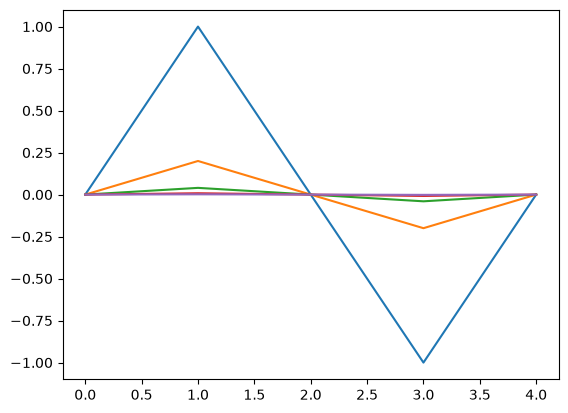

In [72]:
plt.plot(grid)